In [ ]:
# Phase1_Optim.ipynb
# Author: Marianna Gabrielyan, 20260427
# Email: mgabr001@gmail.com

# 


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings('ignore')
import os

import random
from plotnine  import * 

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
import forestci as fci

import dice_ml
from quantile_forest import RandomForestQuantileRegressor
import shap



%matplotlib inline


In [ ]:
# Read in input file

path = '/home/mgabr001/BrainGenix/BrainEmulationChallenge/src/models/autoassociative/NetmorphParOptim'
os.chdir(path)

df = pd.read_excel(open('ParameterSpace_700_samples-labeled.xlsx','rb'))    

print(df.shape)
print(df.columns)



In [ ]:
# Select Only Needed Columns

columnsA = ['days', 'pyramidal', 'interneuron', 'minneuronseparation',
       'shape.radius', 'shape.thickness', 'dm.weight', 'usable_conns1',
       'usable_conns2']


In [ ]:

# correlation matrix
f, ax = plt.subplots(figsize=(9, 6))
k = 10 #number of variables for heatmap
corrmat = df[columnsA].corr()
cols = corrmat.nlargest(k, 'usable_conns2')['usable_conns2'].index
cm = np.corrcoef(df[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()
f.savefig('Correlation_Matrix.png')

In [141]:
df = df[df['usable_conns2'] <= 2500]
df.reset_index(drop=True, inplace=True)

## Create Training and Test datasets: split 80% and 20%

In [ ]:
cols = ['days', 'pyramidal', 'interneuron', 'minneuronseparation',
       'shape.radius', 'shape.thickness', 'dm.weight']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df[cols],df['usable_conns2'], test_size=0.2, random_state=27)
X_train.shape

In [ ]:
print(X_train.head())
print(y_train.head()) 

In [ ]:
clf = RandomForestRegressor(n_estimators=1000, bootstrap = True, oob_score = True, random_state = 27)
model = clf.fit(X_train, y_train)

In [ ]:
# explain the model's predictions using SHAP
# (same syntax works for LightGBM, CatBoost, scikit-learn, transformers, Spark, etc.)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)

# visualize the first prediction's explanation
shap.plots.waterfall(shap_values[0])

In [ ]:
# shap.summary_plot(shap_values, X_train)

In [ ]:
# summarize the effects of all the features
shap.plots.beeswarm(shap_values)

In [ ]:
# shap.TreeExplainer(model).shap_interaction_values(X_train)

In [ ]:
# visualize the first prediction's explanation with a force plot
shap.plots.force(shap_values[0], matplotlib=True)

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(25, 15))

shap.plots.scatter(shap_values[:, "days"], ax=axes[0, 0], color=shap_values, show=False)
shap.plots.scatter(shap_values[:, "pyramidal"], ax=axes[0, 1], color=shap_values, show=False)
shap.plots.scatter(shap_values[:, "dm.weight"], ax=axes[0, 2], color=shap_values, show=False)
shap.plots.scatter(shap_values[:, "interneuron"], ax=axes[1, 0], color=shap_values, show=False)
shap.plots.scatter(shap_values[:, "shape.radius"], ax=axes[1, 1], color=shap_values, show=False)
shap.plots.scatter(shap_values[:, "shape.thickness"], ax=axes[1, 2], color=shap_values, show=False)
shap.plots.scatter(shap_values[:, "minneuronseparation"], ax=axes[2, 0], color=shap_values, show=False)

plt.show()

In [ ]:
shap_values.shape

In [ ]:
shap_values[0]

In [ ]:
# create a dependence scatter plot to show the effect of a single feature across the whole dataset
shap.plots.scatter(shap_values[:, "days"], color=shap_values)

In [ ]:
# create a dependence scatter plot to show the effect of a single feature across the whole dataset
shap.plots.scatter(shap_values[:, "pyramidal"], color=shap_values)

In [ ]:
# create a dependence scatter plot to show the effect of a single feature across the whole dataset
shap.plots.scatter(shap_values[:, "interneuron"], color=shap_values)


In [ ]:
shap.plots.scatter(shap_values[:, "minneuronseparation"], color=shap_values)

In [ ]:
shap.plots.scatter(shap_values[:, "shape.radius"], color=shap_values)

In [ ]:
shap.plots.scatter(shap_values[:, "shape.thickness"], color=shap_values)

In [ ]:
shap.plots.scatter(shap_values[:, "dm.weight"], color=shap_values)

In [ ]:
shap.plots.bar(shap_values)

## Create Paartial Dependence Plots (PDP)

#### PDP = average of model outcomes for fixed feature xi, while others vary.

In [ ]:
shap.partial_dependence_plot(
    "days",
    model.predict,
    X_test[cols],
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

In [ ]:
shap.partial_dependence_plot(
    "pyramidal",
    model.predict,
    X_test[cols],
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

In [ ]:
shap.partial_dependence_plot(
    "dm.weight",
    model.predict,
    X_test[cols],
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

In [ ]:
shap.partial_dependence_plot(
    "interneuron",
    model.predict,
    X_test[cols],
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

In [ ]:
shap.partial_dependence_plot(
    "shape.radius",
    model.predict,
    X_test[cols],
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

In [ ]:
shap.partial_dependence_plot(
    "shape.thickness",
    model.predict,
    X_test[cols],
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

In [ ]:
shap.partial_dependence_plot(
    "minneuronseparation",
    model.predict,
    X_test[cols],
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

#### Recreate Training and Test Datasets to make sure there are no additional columns

In [142]:
X_train, X_test, y_train, y_test = train_test_split(df[cols],df['usable_conns2'], test_size=0.2)
X_train.shape

(557, 7)

# Generate Diverse Counterfactual Explanations (DiCE)

In [143]:
qrf = RandomForestQuantileRegressor(n_estimators=1000, bootstrap = True, oob_score = True, default_quantiles=0.025)
qrf.fit(X_train, y_train)

# If your oob_score is high (e.g., > 0.8), model is generalizing well.
# If your oob_score is low but your training score is high, your model is "memorizing" the training simulations 
# and your uncertainty intervals (error bars) will be lies—they will look small, but the model will fail on new unseen simulations.

print("OOB Score = ", qrf.oob_score_)

# Get OOB predictions (Predictions on the training set using only 'unseen' trees)
# This is a 'honest' way to see how the model performs on known data
oob_preds = qrf.predict(X_train[cols], quantiles=[0.025, 0.5, 0.975], oob_score=True)

# Check: Do ~95% of your actual training labels fall within these OOB intervals?
# If yes, your error bars are well-calibrated.

# Separate the OOB bounds
oob_lower = oob_preds[:, 0]
oob_median = oob_preds[:, 1]
oob_upper = oob_preds[:, 2]


OOB Score =  0.8465648131261202


#### Predict usable_conns2 on training data using Best Fit Model

Create Upper and lower bounds of 95% Prediction Interval for each prediction in the Training and Test Datasets.

In [144]:
# predict on training data
X_train['Pred_usable_conns2'] = oob_median
X_train['lower']=oob_lower
X_train['upper']=oob_upper
X_train['usable_conns2'] = y_train


In [ ]:
# Predict on test data. Since the Model has never seen test data, we can use the full model (all trees) to predict on test data (No need for OOB).

X_test['Pred_usable_conns2'] = qrf.predict(X_test[cols], quantiles=0.5)
X_test['lower']=qrf.predict(X_test[cols], quantiles=0.025) 
X_test['upper']=qrf.predict(X_test[cols], quantiles=0.975) 
X_test['usable_conns2'] = y_test

In [146]:
X_train.head()

,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2,lower,upper,usable_conns2
323,22,88,120,15,180,20,0.6,564.0,0.0,1228.0,266
200,25,56,48,10,150,40,0.7,498.0,164.5,717.0,245
254,23,104,128,15,190,30,0.4,560.0,266.0,1358.5,330
68,20,56,88,10,130,50,0.2,85.0,15.0,275.0,56
428,25,88,56,12,150,40,0.8,848.0,489.4,1730.0,1487


In [147]:
X_test.head()

,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2,lower,upper,usable_conns2
51,24,80,48,10,140,40,0.2,208.0,79.400,414.55,288
98,21,120,128,12,200,40,0.6,718.0,253.000,1696.00,624
521,21,128,40,15,130,30,0.2,353.0,108.000,1421.00,407
686,24,112,120,15,170,50,0.2,519.0,122.625,972.00,566
198,22,104,128,13,190,30,0.6,502.0,266.000,1207.00,695


In [148]:

# 2. Create a "Conservative" Model Wrapper
# This wrapper tells the optimizer to look at the BOTTOM of the 95% interval
# Conservative Strategy: Optimize features until the bottom of the 95% interval is above the threshold. This ensures we hit our goal with 97.5% confidence (one-tailed).
class ConservativeModel:
    def __init__(self, model, threshold):
        self.model = model
        self.threshold = threshold
    
    def predict(self, instances):
        # We predict the 0.025 quantile (Lower Bound)
        # If the Lower Bound > threshold, we are 97.5% sure the real value is too.
        return self.model.predict(instances, quantiles=0.025)

In [149]:

# Wrap the model for DiCE
conservative_wrapper = ConservativeModel(qrf, threshold=500)
m = dice_ml.Model(model=conservative_wrapper, backend="sklearn", model_type='regressor')

# 3. Setup DiCE with specific NETMORPH features
# Setup Data with discrete ranges
# Even if they are integers, we list them in continuous_features 
# so DiCE can explore the range [min, max]
d = dice_ml.Data(dataframe=pd.concat([X_train[cols], y_train], axis=1), 
                 continuous_features=cols, 
                 outcome_name='usable_conns2')

exp = dice_ml.Dice(d, m, method="random")


In [150]:

# 4. Generate Counterfactuals
# We search for parameters where the LOWER BOUND of the model is > threshold
query_instance = X_test[cols].iloc[0:2]
dice_exp = exp.generate_counterfactuals(
    query_instance, 
    total_CFs=7, 
    desired_range=[500.0, 2500.0], # Target range for the lower bound
    permitted_range={'days': [20,25], 
                     'pyramidal': [16, 128], 
                     'interneuron': [16, 128], 
                     'minneuronseparation': [10, 15], 
                     'shape.radius': [100, 200], 
                     'shape.thickness': [20.0, 50.0], 
                     'dm.weight': [0.1, 1.0]},
    features_to_vary=list(cols)
)

dice_exp.visualize_as_dataframe(show_only_changes=True)

cf_df = dice_exp.cf_examples_list[0].final_cfs_df



  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:04<00:00,  2.30s/it]

Query instance (original outcome : 79.0)


,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,usable_conns2
0,24,80,48,10,140,40,0.2,79.0



Diverse Counterfactual set (new outcome: [500.0, 2500.0])


,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,usable_conns2
0,-,105.0,-,-,-,-,0.7,797.0
1,-,85.0,-,-,-,-,0.9,539.0
2,-,128.0,-,-,-,-,0.6,914.0
3,-,121.0,-,-,-,-,0.7,890.0
4,-,102.0,-,-,-,-,0.5,560.0
5,-,108.0,-,-,-,-,0.5,560.0
6,-,112.0,-,-,-,-,1.0,848.0


Query instance (original outcome : 253.0)


,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,usable_conns2
0,21,120,128,12,200,40,0.6,253.0



Diverse Counterfactual set (new outcome: [500.0, 2500.0])


,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,usable_conns2
0,23.0,-,23.0,-,145.0,-,-,689.0
1,23.0,-,-,-,142.0,-,0.8,803.0
2,-,-,-,-,126.0,-,0.9,501.125
3,24.0,-,18.0,-,-,-,0.9,704.5999755859375
4,-,-,-,-,124.0,-,1.0,501.125
5,25.0,-,38.0,-,-,-,0.8,717.6749877929688
6,23.0,-,33.0,-,-,-,0.9,705.0


In [151]:
print(cf_df.shape)
print(cf_df)


(7, 8)
   days  pyramidal  interneuron  minneuronseparation  shape.radius  \
0    24        105           48                   10           140   
1    24         85           48                   10           140   
2    24        128           48                   10           140   
3    24        121           48                   10           140   
4    24        102           48                   10           140   
5    24        108           48                   10           140   
6    24        112           48                   10           140   

   shape.thickness  dm.weight  usable_conns2  
0               40        0.7          797.0  
1               40        0.9          539.0  
2               40        0.6          914.0  
3               40        0.7          890.0  
4               40        0.5          560.0  
5               40        0.5          560.0  
6               40        1.0          848.0  


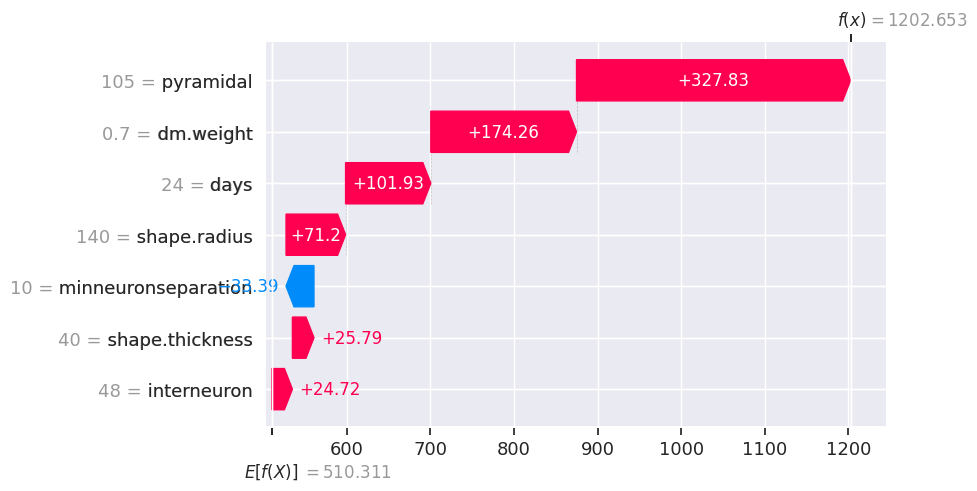

In [152]:
shap_values_cf = explainer(cf_df[cols])
# visualize the cf prediction's explanation
shap.plots.waterfall(shap_values_cf[0])

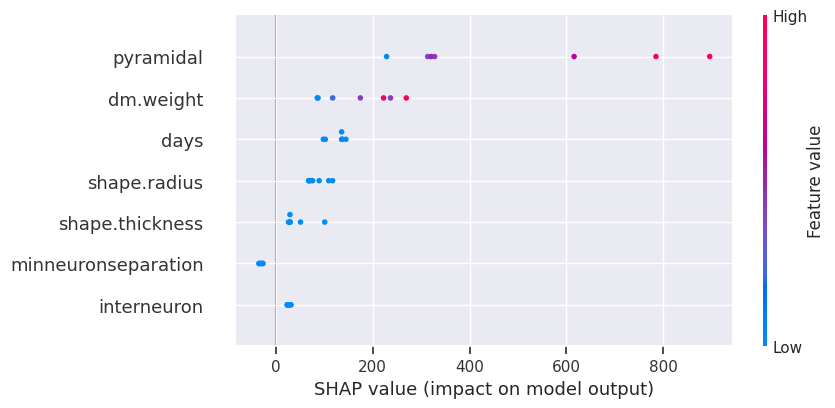

In [153]:
shap.plots.beeswarm(shap_values_cf)

In [154]:
dice_exp.cf_examples_list[0].final_cfs_df

,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,usable_conns2
0,24,105,48,10,140,40,0.7,797.0
1,24,85,48,10,140,40,0.9,539.0
2,24,128,48,10,140,40,0.6,914.0
3,24,121,48,10,140,40,0.7,890.0
4,24,102,48,10,140,40,0.5,560.0
5,24,108,48,10,140,40,0.5,560.0
6,24,112,48,10,140,40,1.0,848.0


In [155]:
X_train.sort_values(by='usable_conns2', ascending=False, inplace = True)
X_train.reset_index(drop=True, inplace=True)


X_test.sort_values(by='usable_conns2', ascending=False, inplace = True)
X_test.reset_index(drop=True, inplace=True)

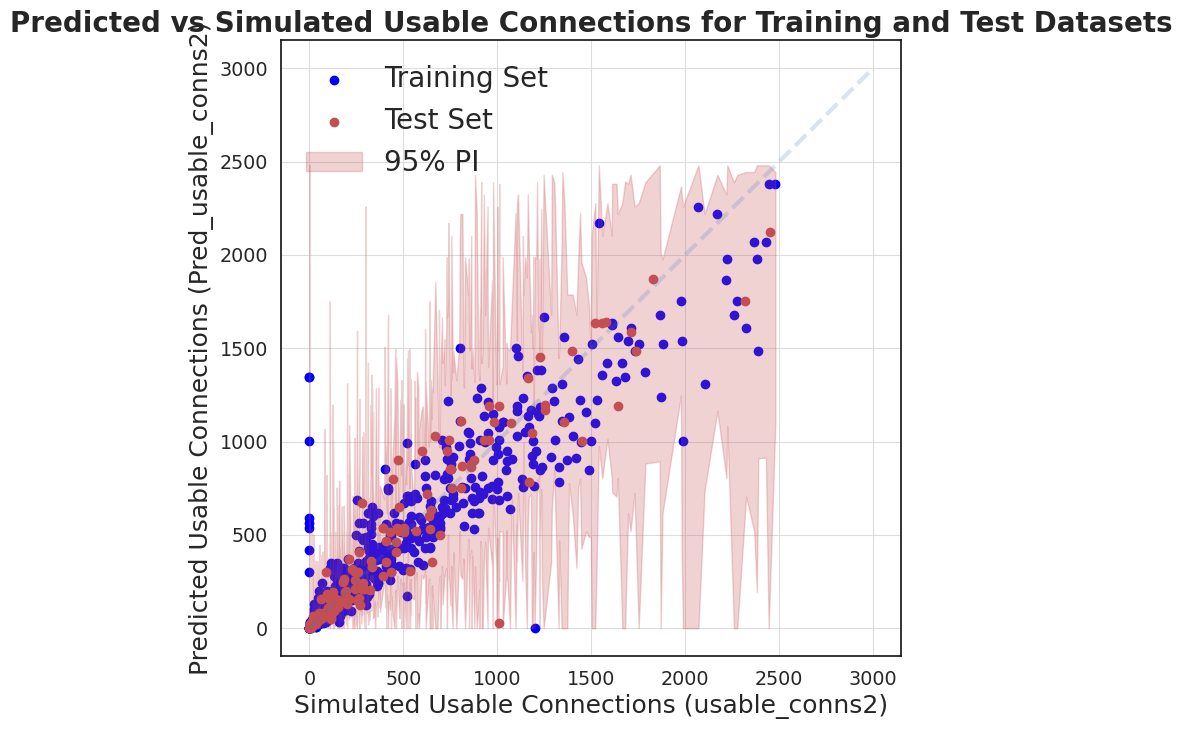

In [156]:
f, ax = plt.subplots(figsize=(8, 8))

plt.scatter(X_train['usable_conns2'], X_train['Pred_usable_conns2'], color ='blue', label = 'Training Set')
plt.scatter(X_test['usable_conns2'],  X_test['Pred_usable_conns2'],color ='r', label = 'Test Set')
# plt.errorbar(X_test['usable_conns2'],  X_test['Pred_usable_conns2'], yerr = X_test['Pred_Usable_Conns_Err'], fmt='o',color ='r', label = 'Test Set')

# plt.fill_between(X_train['usable_conns2'], X_train['Pred_usable_conns2']-1.96*X_train['Pred_Usable_Conns_Err'], X_train['Pred_usable_conns2'] + 1.96*X_train['Pred_Usable_Conns_Err'], color='r', alpha=0.25, label = '95% CI')
# plt.scatter(X_train['usable_conns2'], X_train['Pred_usable_conns2']-1.96*X_train['Pred_Usable_Conns_Err'], color ='cyan', marker='+' )
# plt.scatter(X_train['usable_conns2'], X_train['Pred_usable_conns2']+1.96*X_train['Pred_Usable_Conns_Err'], color ='green', marker='+' )

plt.fill_between(X_train['usable_conns2'], X_train['lower'], X_train['upper'], color='r', alpha=0.25, label = '95% PI')
# plt.scatter(X_train['usable_conns2'], X_train['lower'], color ='cyan', marker='+' )
# plt.scatter(X_train['usable_conns2'], X_train['upper'], color ='green', marker='+' )

plt.plot(np.linspace(0,3000,300), np.linspace(0,3000, 300), 'b--', linewidth=3, alpha= 0.2)

plt.gca().set_facecolor('xkcd:white')
ax.grid(which='major', color='#DDDDDD', linewidth=0.8)


ax.spines['bottom'].set_color('k')
ax.spines['top'].set_color('k')
ax.spines['left'].set_color('k')
ax.spines['right'].set_color('k')

# plt.xlim([0,3500])
# plt.ylim([0,3500])
plt.rc('font', size=18) 
plt.rc('font', size=18) 

plt.title('Predicted vs Simulated Usable Connections for Training and Test Datasets',size = 20, fontweight="bold")
plt.xlabel('Simulated Usable Connections (usable_conns2)',size =18)
plt.ylabel('Predicted Usable Connections (Pred_usable_conns2)',size = 18)
plt.legend(loc='upper left', prop={'size': 20},framealpha=0.)
plt.show()
# f.savefig('Pred_vs_Sim_UsableConns.png')

In [157]:
X_train[(X_train['usable_conns2']==0) & (X_train['Pred_usable_conns2'] > 0)]

,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2,lower,upper,usable_conns2
539,21,24,56,12,160,20,0.1,1.0,0.0,32.1,0
540,25,120,112,10,110,20,0.6,1346.0,0.0,2429.0,0
542,21,24,48,14,190,20,0.1,1.0,0.0,35.0,0
543,21,80,104,15,110,20,0.4,535.0,0.0,1004.0,0
544,25,120,16,10,100,20,0.8,1346.0,0.0,2480.0,0
546,20,16,72,10,110,30,0.1,3.0,1.0,98.0,0
548,24,80,112,13,100,20,1.0,1004.0,0.0,1497.0,0
550,21,80,128,13,110,20,0.9,589.5,0.0,1185.0,0
552,22,112,80,10,100,20,0.1,299.0,0.0,1010.0,0
553,20,104,104,13,110,20,0.3,418.0,0.0,1237.0,0


In [164]:
X_train[(X_train['usable_conns2'] > 0) & (X_train['Pred_usable_conns2'] == 0.0)]

,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2,lower,upper,usable_conns2
65,21,96,112,13,100,50,0.7,0.0,0.0,1988.0,1198
537,20,24,48,15,190,30,0.1,0.0,0.0,47.0,1


## Create Full Grid

In [158]:
# Generate the FULL parameter Space

days = np.arange(20, 26, 1)                         # 6
pyramidal= np.arange(16, 136, 8)                    # 15        
interneuron = np.arange(16, 136, 8)                 # 15
minneuronseparation = np.arange(10, 16, 1)          # 6
shape_radius = np.arange(100, 210, 10)              # 11  
shape_thickness = np.arange(20, 60, 10)             # 4
dm_weight = np.arange(0.1, 1.1, 0.1)                # 10

ldays = len(days)
lpyramidal = len(pyramidal)
linterneuron = len(interneuron)     
lminneuronseparation = len(minneuronseparation)
lshape_radius = len(shape_radius)
lshape_thickness = len(shape_thickness)
ldm_weight = len(dm_weight) 




In [159]:
N = ldays * lpyramidal * linterneuron * lminneuronseparation * lshape_radius * lshape_thickness * ldm_weight
print("N = ", N)
#full grid
arr=[(N,9)]

#######  When created this way, the first row should not be dropped when creating the prediction grid.

arr = [[ days[i], pyramidal[j], interneuron[k], minneuronseparation[l], shape_radius[m], shape_thickness[n], dm_weight[ii] ] \
    for i in range(ldays) \
    for j in range(lpyramidal) \
    for k in range(linterneuron) \
    for l in range(lminneuronseparation) \
    for m in range(lshape_radius) \
    for n in range(lshape_thickness) \
    for ii in range(ldm_weight)]
  

N =  3564000


In [160]:
print("Length of arr:", len(arr))

Length of arr: 3564000


In [161]:
print(arr[:1 :])

[[np.int64(20), np.int64(16), np.int64(16), np.int64(10), np.int64(100), np.int64(20), np.float64(0.1)]]


# Create a prediction array for the entire parameter space

In [162]:
# Create a prediction array for the entire parameter space

cols = ['days', 
        'pyramidal', 
        'interneuron', 
        'minneuronseparation',
        'shape.radius', 
        'shape.thickness', 
        'dm.weight'
        ]

pred_grid = pd.DataFrame(data = arr, columns = cols)

# pred_grid.drop_duplicates(keep='first', inplace=True)
# pred_grid = pred_grid.iloc[1:]  # drop the first row. 1st row is the total # rows and columns 
pred_grid.shape


(3564000, 7)

In [163]:
pred_grid.head()

,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight
0,20,16,16,10,100,20,0.1
1,20,16,16,10,100,20,0.2
2,20,16,16,10,100,20,0.3
3,20,16,16,10,100,20,0.4
4,20,16,16,10,100,20,0.5


# Predict Usable Connections for the entire parameter space using Best FIT model.

In [167]:
# Make predictions using the Quantile RF regressor on the entire parameter space grid.

# Get OOB predictions (Predictions on the training set using only 'unseen' trees)
# This is a 'honest' way to see how the model performs on known data
oob_preds = qrf.predict(pred_grid[cols], quantiles=[0.025, 0.5, 0.975])

# Check: Do ~95% of your actual training labels fall within these OOB intervals?
# If yes, your error bars are well-calibrated.

# Separate the OOB bounds
oob_lower = oob_preds[:, 0]
oob_median = oob_preds[:, 1]
oob_upper = oob_preds[:, 2]

pred_grid['Pred_usable_conns2'] = oob_median
pred_grid['lower'] = oob_lower
pred_grid['upper'] = oob_upper

In [168]:
pred_grid.sort_values(by='Pred_usable_conns2', ascending=False, inplace = True)
pred_grid.reset_index(drop=True, inplace=True)
pred_grid.head()


,days,pyramidal,interneuron,minneuronseparation,shape.radius,shape.thickness,dm.weight,Pred_usable_conns2,lower,upper
0,25,120,40,13,130,50,0.8,2480.0,1380.125,2480.0
1,25,120,40,13,130,50,0.9,2480.0,1540.000,2480.0
2,25,120,32,13,120,50,0.8,2480.0,1540.000,2480.0
3,25,120,32,13,130,40,0.8,2480.0,1307.000,2480.0
4,25,120,40,13,130,50,0.7,2480.0,1307.000,2480.0
